# DM CIPAT TOPIC: AI Based Internship Recommendation system
## Team members:
### DIV - D | Batch - D1
230090107043 - Hetvi Doshi  
230090107119 - Aryan Patel  

### DIV - D | Batch - D3
230090107023 - Rushang Desai    
230090107034 - Fenil Dudhat

### **Data Cleaning**

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [108]:
df_original = pd.read_csv("internships.csv")

In [109]:
df_dirty = df_original.copy()

In [110]:
df_dirty.loc[0, "stipend"] = np.nan
df_dirty.loc[1, "Company name"] = np.nan

df_dirty = pd.concat([df_dirty, df_dirty.iloc[[2]]], ignore_index=True)

df_dirty.loc[3, "Role"] = " software development "
df_dirty.loc[4, "offline / online"] = "online "

print("Dirty data sample:")
print(df_dirty.head())

Dirty data sample:
  Internship Id Company name Internship location offline / online  \
0      INT-1000     Deloitte  Bengaluru (Hybrid)           Hybrid   
1      INT-1001          NaN           Hyderabad           Online   
2      INT-1002     Deloitte           Bengaluru          Offline   
3      INT-1003     Deloitte           Bengaluru           Online   
4      INT-1004     Deloitte  Hyderabad (Hybrid)          online    

         stipend                                     skill required  \
0            NaN                       Selenium, JIRA, Bug Tracking   
1  ₹34,442/month                            JavaScript, Python, SQL   
2  ₹34,959/month        Figma, User Research, Adobe XD, Prototyping   
3  ₹34,974/month           Sales, Client Relations, Market Analysis   
4  ₹32,647/month  Automation Testing, Bug Tracking, Manual Testi...   

                    experience  \
0                    0-1 years   
1                      Fresher   
2           Portfolio required   
3  

In [111]:
df_clean = df_dirty.copy()
df_clean["stipend"].fillna("₹0/month", inplace=True)
df_clean["Company name"].fillna("Unknown", inplace=True)

df_clean.drop_duplicates(inplace=True)

df_clean["Role"] = df_clean["Role"].str.strip().str.title()
df_clean["offline / online"] = df_clean["offline / online"].str.strip().str.title()

df_clean.reset_index(drop=True, inplace=True)

print("\nCleaned data sample:")
print(df_clean.head())


Cleaned data sample:
  Internship Id Company name Internship location offline / online  \
0      INT-1000     Deloitte  Bengaluru (Hybrid)           Hybrid   
1      INT-1001      Unknown           Hyderabad           Online   
2      INT-1002     Deloitte           Bengaluru          Offline   
3      INT-1003     Deloitte           Bengaluru           Online   
4      INT-1004     Deloitte  Hyderabad (Hybrid)           Online   

         stipend                                     skill required  \
0       ₹0/month                       Selenium, JIRA, Bug Tracking   
1  ₹34,442/month                            JavaScript, Python, SQL   
2  ₹34,959/month        Figma, User Research, Adobe XD, Prototyping   
3  ₹34,974/month           Sales, Client Relations, Market Analysis   
4  ₹32,647/month  Automation Testing, Bug Tracking, Manual Testi...   

                    experience  \
0                    0-1 years   
1                      Fresher   
2           Portfolio required   


In [112]:
print("Original dataset shape:", df_original.shape)
print("Dirty dataset shape:", df_dirty.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (354, 13)
Dirty dataset shape: (355, 13)
Cleaned dataset shape: (354, 13)


In [113]:
df = pd.read_csv("internships.csv")
df.shape

(354, 13)

In [114]:
df.columns

Index(['Internship Id', 'Company name', 'Internship location',
       'offline / online', 'stipend', 'skill required', 'experience',
       'about the job', 'deadline for apply', 'number of opening', 'duration',
       'Role', 'Website link of company (optional)'],
      dtype='object')

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Internship Id                       354 non-null    object
 1   Company name                        354 non-null    object
 2   Internship location                 354 non-null    object
 3   offline / online                    354 non-null    object
 4   stipend                             354 non-null    object
 5   skill required                      354 non-null    object
 6   experience                          354 non-null    object
 7   about the job                       354 non-null    object
 8   deadline for apply                  354 non-null    object
 9   number of opening                   354 non-null    int64 
 10  duration                            354 non-null    object
 11  Role                                354 non-null    object

In [116]:
df.head()

,Internship Id,Company name,Internship location,offline / online,stipend,skill required,experience,about the job,deadline for apply,number of opening,duration,Role,Website link of company (optional)
0,INT-1000,Deloitte,Bengaluru (Hybrid),Hybrid,"₹33,794/month","Selenium, JIRA, Bug Tracking",0-1 years,"Test software applications, identify bugs, wri...",11-11-2025,4,4 months,Quality Assurance,https://www.deloitte.com
1,INT-1001,Deloitte,Hyderabad,Online,"₹34,442/month","JavaScript, Python, SQL",Fresher,"Develop and maintain software applications, wo...",10-18-2025,4,3 months,Software Development,https://www.deloitte.com
2,INT-1002,Deloitte,Bengaluru,Offline,"₹34,959/month","Figma, User Research, Adobe XD, Prototyping",Portfolio required,"Design user interfaces, conduct user research,...",11-6-2025,11,6 months,UI/UX Design,https://www.deloitte.com
3,INT-1003,Deloitte,Bengaluru,Online,"₹34,974/month","Sales, Client Relations, Market Analysis",Strong communication skills,"Support sales processes, conduct market resear...",11-1-2025,15,3 months,Business Development,https://www.deloitte.com
4,INT-1004,Deloitte,Hyderabad (Hybrid),Hybrid,"₹32,647/month","Automation Testing, Bug Tracking, Manual Testi...",Understanding of SDLC,"Test software applications, identify bugs, wri...",9-30-2025,21,4 months,Quality Assurance,https://www.deloitte.com


In [117]:
df.tail()

,Internship Id,Company name,Internship location,offline / online,stipend,skill required,experience,about the job,deadline for apply,number of opening,duration,Role,Website link of company (optional)
349,INT-1349,IDRBT,Hyderabad,Online,"₹13,838/month","Market Analysis, Client Relations, CRM",Strong communication skills,"Support sales processes, conduct market resear...",11-7-2025,25,3 months,Business Development,https://www.idrbt.ac.in
350,INT-1350,IDRBT,Hyderabad,Offline,"₹12,886/month","Selenium, Manual Testing, Automation Testing",0-1 years,"Test software applications, identify bugs, wri...",11-12-2025,23,2 months,Quality Assurance,https://www.idrbt.ac.in
351,INT-1351,IDRBT,Hyderabad (Hybrid),Hybrid,"₹14,779/month","Negotiation, Client Relations, Market Analysis...",Strong communication skills,"Support sales processes, conduct market resear...",10-24-2025,17,6 months,Business Development,https://www.idrbt.ac.in
352,INT-1352,IDRBT,Hyderabad (Hybrid),Hybrid,"₹14,806/month","Figma, Adobe XD, User Research",0-1 years,"Design user interfaces, conduct user research,...",10-5-2025,11,6 months,UI/UX Design,https://www.idrbt.ac.in
353,INT-1353,IDRBT,Hyderabad,Offline,"₹14,654/month","Google Analytics, SEO, Content Marketing, PPC,...",0-1 years,"Manage digital campaigns, create content strat...",10-21-2025,15,3 months,Digital Marketing,https://www.idrbt.ac.in


In [118]:
df.describe()

,number of opening
count,354.000000
mean,13.881356
std,6.981768
min,2.000000
25%,8.000000
50%,14.000000
75%,20.000000
max,25.000000


In [119]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number of opening,354.0,13.881356,6.981768,2.0,8.0,14.0,20.0,25.0


In [120]:
df.isnull()

,Internship Id,Company name,Internship location,offline / online,stipend,skill required,experience,about the job,deadline for apply,number of opening,duration,Role,Website link of company (optional)
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,False,False,False,False,False,False,False,False,False,False,False,False,False
350,False,False,False,False,False,False,False,False,False,False,False,False,False
351,False,False,False,False,False,False,False,False,False,False,False,False,False
352,False,False,False,False,False,False,False,False,False,False,False,False,False


In [121]:
df.isnull().sum()

,0
Internship Id,0
Company name,0
Internship location,0
offline / online,0
stipend,0
skill required,0
experience,0
about the job,0
deadline for apply,0
number of opening,0


In [122]:
mode_count = df["offline / online"].value_counts()
print(mode_count)

offline / online
Online     141
Hybrid     111
Offline    102
Name: count, dtype: int64


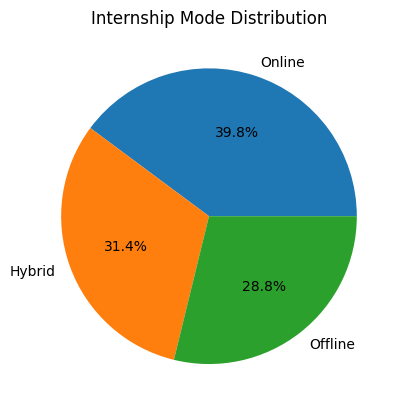

In [123]:
mode_count.plot(kind="pie", autopct="%1.1f%%")
plt.title("Internship Mode Distribution")
plt.ylabel("")
plt.show()

In [124]:
roles = df["Role"].value_counts()
print(roles)

Role
UI/UX Design            39
Quality Assurance       36
Business Development    34
Digital Marketing       32
Operations              30
HR                      29
Data Science            29
Software Development    27
Machine Learning        27
Product Management      26
Finance                 23
Content Writing         22
Name: count, dtype: int64


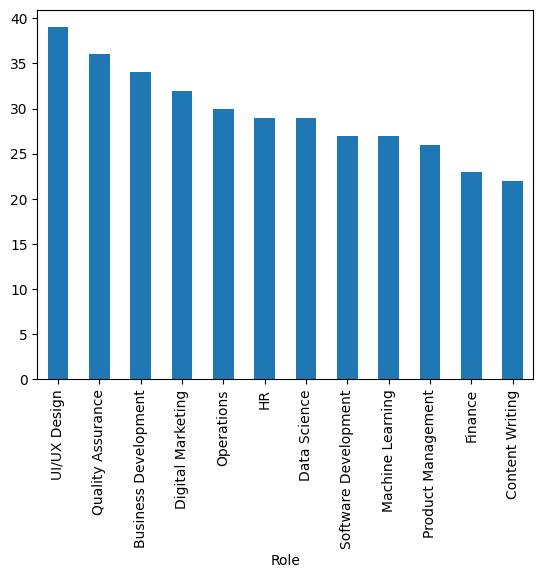

In [125]:
roles.plot(kind='bar')
plt.show()

In [126]:
locations = df["Internship location"].value_counts()
print(locations)

Internship location
Bengaluru                      79
Bengaluru (Hybrid)             38
Delhi                          36
Hyderabad                      25
Hyderabad (Hybrid)             24
Mumbai                         23
Pune                           22
Remote                         18
Chennai (Hybrid)               17
Chennai                        14
Delhi (Hybrid)                 13
Gurgaon                         9
Mumbai (Hybrid)                 7
Thiruvananthapuram              7
Noida                           5
Mangalore (Hybrid)              5
Mangalore                       3
Pune (Hybrid)                   3
Sydney                          2
Sydney (Hybrid)                 2
Thiruvananthapuram (Hybrid)     2
Name: count, dtype: int64


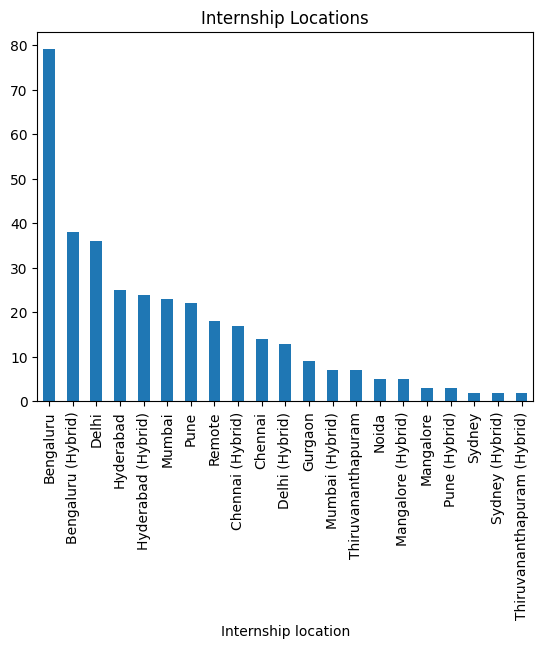

In [127]:
locations.plot(kind='bar')
plt.title("Internship Locations")
plt.show()

In [128]:
print(df["duration"].value_counts())

duration
2 months     80
4 months     73
6 months     73
3 months     70
12 months    58
Name: count, dtype: int64


In [129]:
df["stipend_clean"] = df["stipend"].str.replace("₹|,|/month", "", regex=True)

df["stipend_clean"] = pd.to_numeric(df["stipend_clean"], errors="coerce")

print("Average stipend:", df["stipend_clean"].mean())
print("Max stipend:", df["stipend_clean"].max())
print("Min stipend:", df["stipend_clean"].min())

Average stipend: 37804.443502824855
Max stipend: 99521
Min stipend: 12705


### **Data Integration**

 - In this project, we only have one main dataset. If multiple datasets existed, we would use pd.merge() to combine them using appropriate inner/left/right joins based on key columns.

### **Data Transformation**


In [130]:
# Normalization (Min-Max Scaling)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["stipend_scaled"] = scaler.fit_transform(df[["stipend_clean"]])

print(df[["stipend_clean", "stipend_scaled"]].head())

# scaled stipend values between 0 and 1

   stipend_clean  stipend_scaled
0          33794        0.242916
1          34442        0.250380
2          34959        0.256335
3          34974        0.256508
4          32647        0.229704


In [131]:
# Standardization (Z-score Scaling)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["stipend_standard"] = scaler.fit_transform(df[["stipend_clean"]])

print(df[["stipend_clean", "stipend_standard"]].head())

# standardized stipend values to have mean 0 and variance 1

   stipend_clean  stipend_standard
0          33794         -0.223530
1          34442         -0.187412
2          34959         -0.158596
3          34974         -0.157760
4          32647         -0.287460


In [132]:
# Discretization (Binning)

import pandas as pd

df["stipend_category"] = pd.cut(df["stipend_clean"],
                               bins=3,
                               labels=["Low", "Medium", "High"])

print(df[["stipend_clean", "stipend_category"]].head())

# converted continuous stipend values into categories like Low, Medium, and High

   stipend_clean stipend_category
0          33794              Low
1          34442              Low
2          34959              Low
3          34974              Low
4          32647              Low


### **Data Reduction**

In [133]:
# feature selction

df_selected = df[["stipend_clean", "duration", "number of opening"]]

print(df_selected.head())

# selected important features to reduce data complexity

   stipend_clean  duration  number of opening
0          33794  4 months                  4
1          34442  3 months                  4
2          34959  6 months                 11
3          34974  3 months                 15
4          32647  4 months                 21


In [134]:
# Dimensionality Reduction (PCA)

df["duration_clean"] = df["duration"].str.extract('(\d+)').astype(float)

df_selected = df[["stipend_clean", "duration_clean", "number of opening"]]

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_selected.fillna(0))

print(reduced_data[:5])

# Since PCA requires numerical data, we converted the duration column from text into numeric values

[[-4.01044316e+03 -1.00229490e+01]
 [-3.36244317e+03 -9.99620090e+00]
 [-2.84544338e+03 -2.98739459e+00]
 [-2.83044357e+03  1.02299803e+00]
 [-5.15744377e+03  6.93543735e+00]]


In [135]:
import warnings
warnings.filterwarnings('ignore')

### **association rule mining - apriori algorithm**

#### Apriori algorithm to find relationships between skills and internship roles

In [136]:
df["skill_list"] = df["skill required"].str.lower().str.split(",")
df["skill_list"] = df["skill_list"].apply(lambda x: [i.strip() for i in x])

In [137]:
data = df.apply(lambda x: x["skill_list"] + [x["Role"].lower()], axis=1).tolist()

In [138]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit(data).transform(data)

df_te = pd.DataFrame(te_data, columns=te.columns_)

In [139]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(df_te, min_support=0.005, use_colnames=True)

print(frequent_itemsets.head())

    support              itemsets
0  0.050847          (accounting)
1  0.096045            (adobe xd)
2  0.062147               (agile)
3  0.138418           (analytics)
4  0.081921  (automation testing)


In [140]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

print(rules.head())

            antecedents   consequents  antecedent support  consequent support  \
0               (excel)  (accounting)            0.050847            0.050847   
1          (accounting)       (excel)            0.050847            0.050847   
2             (finance)  (accounting)            0.064972            0.050847   
3          (accounting)     (finance)            0.050847            0.064972   
4  (financial analysis)  (accounting)            0.062147            0.050847   

    support  confidence       lift  representativity  leverage  conviction  \
0  0.036723    0.722222  14.203704               1.0  0.034138    3.416949   
1  0.036723    0.722222  14.203704               1.0  0.034138    3.416949   
2  0.050847    0.782609  15.391304               1.0  0.047544    4.366102   
3  0.050847    1.000000  15.391304               1.0  0.047544         inf   
4  0.048023    0.772727  15.196970               1.0  0.044863    4.176271   

   zhangs_metric   jaccard  certainty  kulcz

### **Classification**

In [141]:
from sklearn.model_selection import train_test_split

X = df[["stipend_clean", "duration_clean", "number of opening"]]

y = df["Role"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X.fillna(0), y, test_size=0.2, random_state=42)

In [142]:
# distance based - KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNN Accuracy:", knn.score(X_test, y_test))

# classifies data based on similarity using distance between data points

KNN Accuracy: 0.1267605633802817


In [143]:
# Statistics-Based - Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

print("Naive Bayes Accuracy:", nb.score(X_test, y_test))

# uses probability to classify data assuming feature independence.

Naive Bayes Accuracy: 0.1267605633802817


In [144]:
# Tree-Based - Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt.score(X_test, y_test))
# classifies data using rule-based splitting of features.

Decision Tree Accuracy: 0.014084507042253521


In [145]:
# Neural Network-Based - MLP
# A Multilayer Perceptron (MLP) is a fundamental type of Feedforward Artificial Neural Network (ANN)

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(max_iter=300)
mlp.fit(X_train, y_train)

print("MLP Accuracy:", mlp.score(X_test, y_test))

# learns complex patterns in data

MLP Accuracy: 0.09859154929577464


In [146]:
# random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

# advanced method that combines multiple decision trees for better accuracy

Random Forest Accuracy: 0.08450704225352113


### **Clustering**

In [147]:
from sklearn.preprocessing import StandardScaler

X = df[["stipend_clean", "duration_clean", "number of opening"]].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [148]:
# distance based - K-Means

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

print(labels_kmeans[:100])

[1 1 1 0 0 0 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 1 0 1
 1 1 0 0 0 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 1 0 2 1 0 1 0 0 2 0 0 1 1 0 1 0 0 1 1 1 0 0 2 0 2]


In [149]:
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(X_scaled, labels_kmeans)
print("K-Means Silhouette Score:", score_kmeans)

K-Means Silhouette Score: 0.3331005143457307


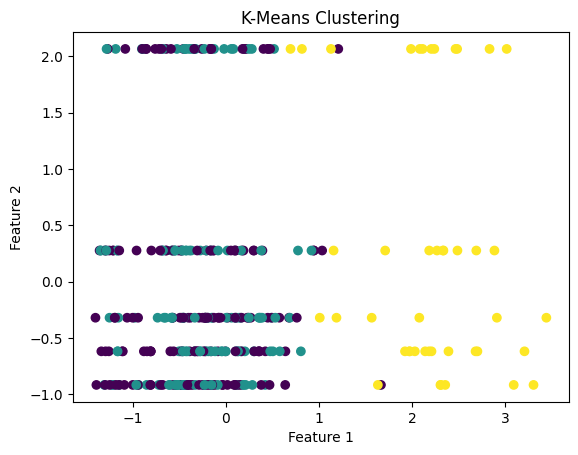

In [150]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_kmeans)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [151]:
# K-Means groups similar internships based on distance, and silhouette score measures clustering quality

In [152]:
# Hierarchical Clustering - Agglomerative

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)

print(labels_agg[:10])

[0 0 0 0 0 0 2 0 0 0]


In [153]:
score_agg = silhouette_score(X_scaled, labels_agg)
print("Hierarchical Silhouette Score:", score_agg)

Hierarchical Silhouette Score: 0.4287175736219397


In [154]:
# DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

db = DBSCAN(eps=0.8, min_samples=5)
labels_db = db.fit_predict(X_scaled)

# DBSCAN may mark some points as noise (-1), exclude them for score
mask = labels_db != -1
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")

if mask.sum() > 1 and n_clusters > 1:
    score_db = silhouette_score(X_scaled[mask], labels_db[mask])
    print("DBSCAN Silhouette Score:", score_db)
else:
    score_db = 0
    print("Not enough clusters for silhouette score")

Clusters found : 2
Noise points   : 15
DBSCAN Silhouette Score: 0.4106874482327924


### **Text mining technique**

In [155]:
#TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Fill missing values
df["skill required"] = df["skill required"].fillna("")

# Apply TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
tfidf = vectorizer.fit_transform(df["skill required"])

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=vectorizer.get_feature_names_out())

print(tfidf_df.head())

   analysis  analytics    market  media  python  relations  research  social  \
0  0.000000        0.0  0.000000    0.0     0.0   0.000000       0.0     0.0   
1  0.000000        0.0  0.000000    0.0     1.0   0.000000       0.0     0.0   
2  0.000000        0.0  0.000000    0.0     0.0   0.000000       1.0     0.0   
3  0.584901        0.0  0.584901    0.0     0.0   0.561944       0.0     0.0   
4  0.000000        0.0  0.000000    0.0     0.0   0.000000       0.0     0.0   

   testing  wireframing  
0      0.0          0.0  
1      0.0          0.0  
2      0.0          0.0  
3      0.0          0.0  
4      1.0          0.0  


Converts text → numbers  
Finds important skills

Example:

"Python, ML" → [0.7, 0.5]

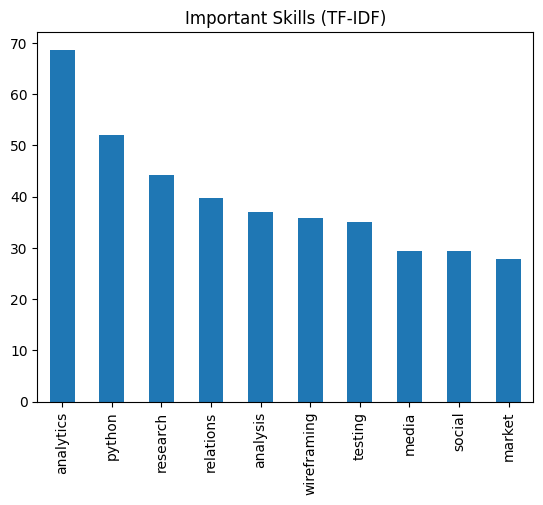

In [156]:
import matplotlib.pyplot as plt

tfidf_df.sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Important Skills (TF-IDF)")
plt.show()

TF-IDF to convert skill text into numerical values and identify important skills in the dataset

### **Web mining technique**

In [157]:
!pip install requests beautifulsoup4

In [158]:
import requests
import pandas as pd

# Fetch data from API
url = "https://remoteok.com/api"
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(url, headers=headers)
data = response.json()[1:]   # skip first element

# Extract useful fields
jobs = []
for job in data:
    jobs.append({
        "Company": job.get("company"),
        "Role": job.get("position"),
        "Location": job.get("location"),
        "Skills": ", ".join(job.get("tags", []))
    })

# Create DataFrame
df_web = pd.DataFrame(jobs)

print(df_web.head())

             Company                                            Role  \
0          Alimentiv      Imaging Research and Development Associate   
1          Headlight             Learning and Development Specialist   
2            Sureify                               VP of Engineering   
3  LifeStance Health                Licensed Mental Health Counselor   
4          Spellbook  Business Development Representative Enterprise   

     Location                                             Skills  
0              design, training, support, voice, management, ...  
1              system, training, support, adult, microsoft, m...  
2          US  technical, software, lead, operational, engine...  
3  Tacoma, WA  lead, medical, health, healthcare, full-time, ...  
4              saas, support, software, test, manager, micros...  


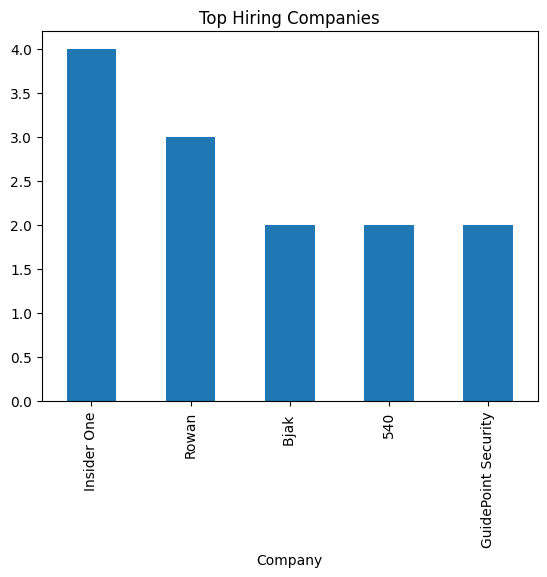

In [159]:
import matplotlib.pyplot as plt

df_web["Company"].value_counts().head(5).plot(kind="bar")
plt.title("Top Hiring Companies")
plt.show()

web mining to extract real-time job data from an online API. The data was processed and analyzed to understand hiring trends and required skills.